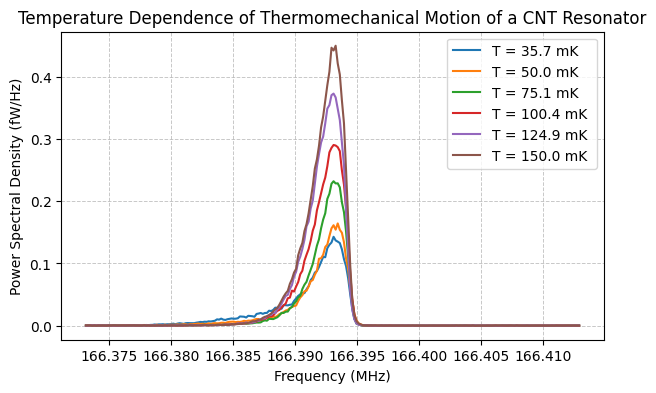

In [10]:
# grc
#HERE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd        
import qcodes as qc


run_ids = [1263, 1265, 1267, 1299, 1303, 1305, 1309, 1311, 1313, 1315,
           1319, 1321, 1323, 1325, 1329, 1331, 1333, 1335, 1339, 1341, 1343, 1345]

temperatures = [35.6766, 35.6766, 35.6766,
                50.0152, 50.0152, 50.0152,
                75.0531, 75.0531, 75.0531, 75.0531,
                100.3800, 100.3800, 100.3800, 100.3800,
                124.8840, 124.8840, 124.8840, 124.8840,
                149.9940, 149.9940, 149.9940, 149.9940]

qc.config["core"]["db_location"] = r"D:\databases CD11_D7_C1\CD11_D7_C1_part3.db"


def extract_1d(run_id,
               data_1d_name="Resistance",
               setpoint_name="single_gate",
               plot=False):
    ds       = qc.load_by_id(run_id)
    par_data = ds.get_parameter_data(data_1d_name)
    freq_raw = par_data[data_1d_name][setpoint_name]
    df_dict  = ds.to_pandas_dataframe_dict()
    psd_raw  = df_dict[data_1d_name]

    freq = np.asarray(freq_raw).flatten()
    psd  = np.asarray(psd_raw).flatten()

    if plot:
        plt.plot(freq, psd)
        plt.title(f"Measurement {run_id}")
        plt.ylabel("Avg PSD (W/Hz)")
        plt.xlabel("Frequency (MHz)")
        plt.show()

    return freq, psd


temp_data       = {}
frequency_array = None

for run_id, temp in zip(run_ids, temperatures):
    freq, psd = extract_1d(run_id,
                           data_1d_name="avg_avg_psd_nodrive",
                           setpoint_name="freq_param",
                           plot=False)

    if frequency_array is None:
        frequency_array = freq
    temp_data.setdefault(temp, []).append(psd)

plt.figure(figsize=(7, 4))

for temp in sorted(temp_data.keys()):
    traces  = np.vstack(temp_data[temp])   # shape: (n_runs, n_freq)
    avg_psd = traces.mean(axis=0)          # averaged PSD per frequency

    # Noise per temperature = minimum of averaged PSD
    noise_level = avg_psd.min()

   
    df = pd.DataFrame({
        'frequency': frequency_array,
        'psd_':      avg_psd,
        'Noise':     noise_level         
    })


    df['psd_minus_noise'] = (
        df['psd_'] + df['Noise'] - (2 * np.sqrt(df['psd_']) * np.sqrt(df['Noise']))
    )
    plt.ticklabel_format(axis='x', style='plain',useOffset=False)
    plt.ticklabel_format(axis='y', style='plain',useOffset=False)
    plt.plot(df['frequency']*1e-6, df['psd_minus_noise']*1e15,
             label=f"T = {temp:.1f} mK ")
plt.ticklabel_format(axis='x', style='plain',useOffset=False)
plt.ticklabel_format(axis='y', style='plain',useOffset=False)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power Spectral Density (fW/Hz)")
plt.title("Temperature Dependence of Thermomechanical Motion of a CNT Resonator")


plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

plt.show()


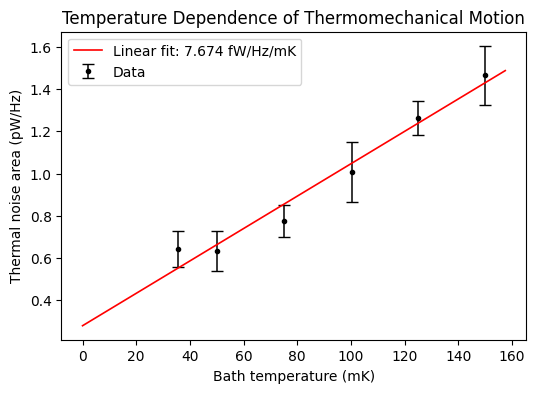

In [11]:
# thesis
temp_data       = {}
frequency_array = None

for run_id, temp in zip(run_ids, temperatures):
    freq, psd = extract_1d(run_id,
                           data_1d_name="avg_avg_psd_nodrive",
                           setpoint_name="freq_param",
                           plot=False)

    if frequency_array is None:
        frequency_array = freq
    temp_data.setdefault(temp, []).append(psd)

# Store areas for each temperature
areas = []
temps = []
area_by_temp = {}


for temp in sorted(temp_data.keys()):
    area_by_temp[temp] = []

    for psd in temp_data[temp]:

        noise_level = psd.min()

        psd_minus_noise = (
            psd + noise_level
            - 2 * np.sqrt(psd) * np.sqrt(noise_level)
        )

        area = np.trapz(psd_minus_noise, frequency_array)
        area_by_temp[temp].append(area)
temps = []
mean_areas = []
std_areas = []

for temp in sorted(area_by_temp.keys()):
    areas = np.array(area_by_temp[temp])

    temps.append(temp)
    mean_areas.append(areas.mean())
    std_areas.append(areas.std())

temps      = np.array(temps)
mean_areas = np.array(mean_areas)
std_areas  = np.array(std_areas)

# Linear fit
coeffs  = np.polyfit(temps, mean_areas * 1e12, 1)  # fit in pW/Hz
fit_line = np.poly1d(coeffs)
fit_x    = np.linspace(0, max(temps) * 1.05, 200)

plt.figure(figsize=(6, 4))
plt.errorbar(
    temps,
    mean_areas * 1e12,
    yerr=std_areas * 1e12,
    fmt="k.", markersize=6,
    capsize=4, elinewidth=1.1, alpha=1,
    label="Data",
)
plt.plot(fit_x, fit_line(fit_x), "r-", linewidth=1.2,
         label=f"Linear fit: {coeffs[0]*1e3:.3f} fW/Hz/mK")
plt.title("Temperature Dependence of Thermomechanical Motion")
plt.xlabel("Bath temperature (mK)")
plt.ylabel(r"Thermal noise area (pW/Hz)")
plt.legend()
plt.show()


Frequency fluctuations

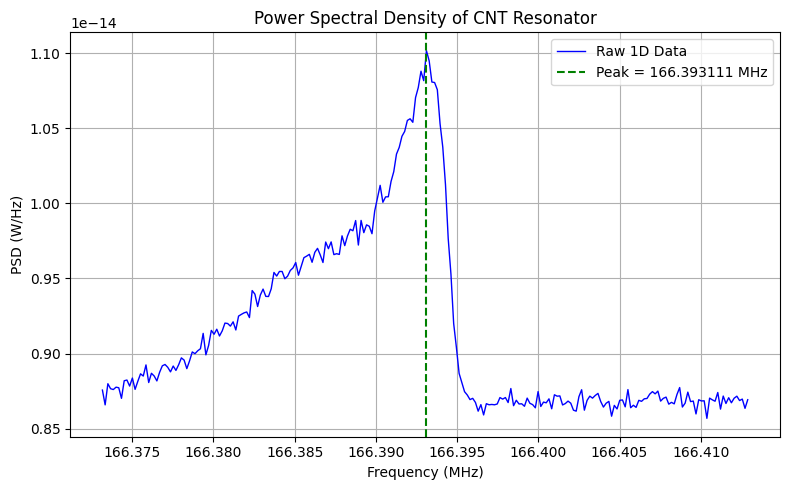

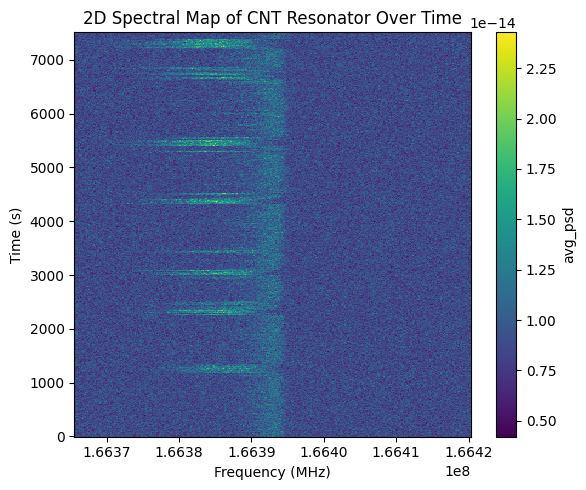

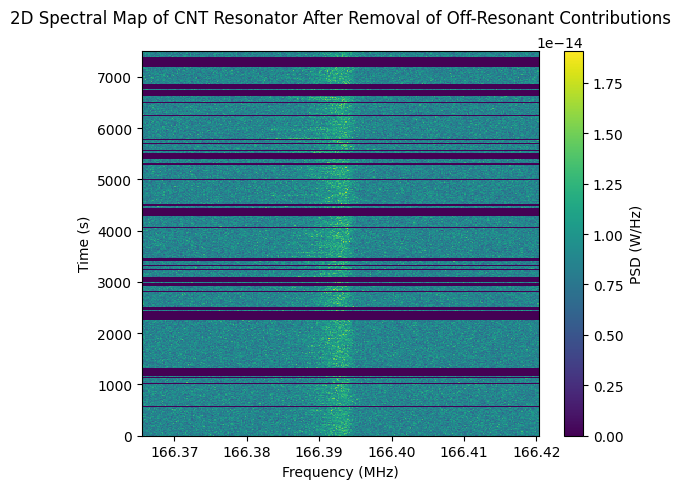

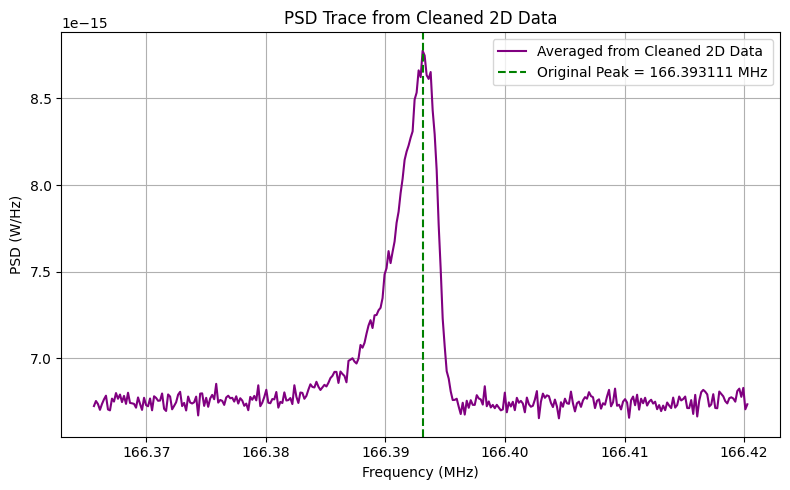

In [12]:
import logging
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, List



qc.config["core"]["db_location"] = r"D:\databases CD11_D7_C1\CD11_D7_C1_part3.db"

def extract_1d(run_id: int, data_1d_name: str = "Resistance", setpoint_name: str = 'single_gate') -> Tuple[np.ndarray, np.ndarray]:

    dataset = qc.load_by_id(run_id)

    data = dataset.get_parameter_data(data_1d_name)
    if setpoint_name not in data[data_1d_name]:
        raise KeyError(f"Setpoint key '{setpoint_name}' not found in the 1D data")
    setpoints_raw = data[data_1d_name][setpoint_name]
    setpoints_np = np.array(setpoints_raw)
    

    df_dict = dataset.to_pandas_dataframe_dict()
    if data_1d_name not in df_dict:
        raise KeyError(f"Data key '{data_1d_name}' not found in the dataset")
    data1d_raw = df_dict[data_1d_name]
    data1d_np = np.array(data1d_raw)
    
    return setpoints_np.flatten(), data1d_np.flatten()

def extract_2d(run_id: int, 
               data_2d_name: str = "avg_psd",
               setpoints1_name: str = 'time_param',
               setpoints2_name: str = 'freq_param',
               plot: bool = True) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:

    dataset = qc.load_by_id(run_id)
    df_dict = dataset.to_pandas_dataframe_dict()
    if data_2d_name not in df_dict:
        raise ValueError(f"Parameter '{data_2d_name}' not found. Available keys: {list(df_dict.keys())}")
    data2d_raw = df_dict[data_2d_name]
    data2d_np = np.array(data2d_raw)
    
 
    interdeps = dataset.description.interdeps
    param_spec = interdeps.non_dependencies[0]
    param_name = param_spec.name
    data_xy = dataset.get_parameter_data(param_spec)
    
    setpoints1_raw = data_xy[param_name][setpoints1_name]
    setpoints2_raw = data_xy[param_name][setpoints2_name]
    setpoints1_np = np.array(setpoints1_raw)
    setpoints2_np = np.array(setpoints2_raw)
    
   
    setpoints1 = np.unique(setpoints1_np)
    setpoints2 = np.unique(setpoints2_np)
    

    data_2d = np.zeros((len(setpoints1), len(setpoints2)))
    for i in range(len(data2d_np)):
        row_idx = np.where(setpoints1 == setpoints1_np[i])[0][0]
        col_idx = np.where(setpoints2 == setpoints2_np[i])[0][0]
        data_2d[row_idx, col_idx] = data2d_np[i]
    
    if plot:
        plt.figure(figsize=(6, 5))
        plt.pcolor(setpoints2, setpoints1, data_2d, shading='auto')
        plt.title(f"2D Spectral Map of CNT Resonator Over Time")
        plt.colorbar(label=data_2d_name)
        plt.xlabel('Frequency (MHz)')
        plt.ylabel('Time (s)')
        plt.tight_layout()
        plt.show()
        
    return setpoints1, setpoints2, data_2d
def main():

    run_ids = [1263]
    temperatures = [35.6766]
    run_ids_2d = [r - 1 for r in run_ids]

    narrow_band_width = 0.005
    outlier_factor = 1.4

    for run_1d, temp, run_2d in zip(run_ids, temperatures, run_ids_2d):


        freq_1d, data_1d = extract_1d(run_1d, data_1d_name="avg_avg_psd_nodrive", setpoint_name='freq_param')
        freq_1d_mhz = freq_1d / 1e6
        peak_index = np.argmax(data_1d)
        peak_freq_mhz = freq_1d_mhz[peak_index]

        freq_min = peak_freq_mhz - narrow_band_width / 2
        freq_max = peak_freq_mhz + narrow_band_width / 2

        mask_1d = (freq_1d_mhz >= freq_min) & (freq_1d_mhz <= freq_max)
        filtered_freq_1d = freq_1d_mhz[mask_1d]
        filtered_data_1d = data_1d[mask_1d]


        plt.figure(figsize=(8, 5))
        plt.plot(freq_1d_mhz, data_1d, label='Raw 1D Data', color='blue', lw=1)
     
        plt.axvline(peak_freq_mhz, color='green', linestyle='--', label=f'Peak = {peak_freq_mhz:.6f} MHz')
        plt.title(f"Power Spectral Density of CNT Resonator")
        plt.xlabel("Frequency (MHz)")
        plt.ylabel("PSD (W/Hz)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


        setpoints_time, setpoints_freq_raw, data_2d = extract_2d(
            run_2d,
            data_2d_name="avg_psd",
            setpoints1_name="time_param",
            setpoints2_name="freq_param",
            plot=True
        )

        setpoints_freq_mhz = setpoints_freq_raw / 1e6 if setpoints_freq_raw.max() > 1e6 else setpoints_freq_raw


        mask_in_band = (setpoints_freq_mhz >= freq_min) & (setpoints_freq_mhz <= freq_max)
        mask_out_of_band = ~mask_in_band

        filtered_data_2d = data_2d.copy()  
        valid_mask = np.ones(data_2d.shape[0], dtype=bool)

        for i in range(data_2d.shape[0]):
            in_band_values = data_2d[i, mask_in_band]
            out_band_values = data_2d[i, mask_out_of_band]

            if in_band_values.size == 0:
                continue

            ref_mean = np.mean(in_band_values)
            if ref_mean and out_band_values.size > 0 and out_band_values.max() > outlier_factor * ref_mean:
                logging.info(f"Zeroing time row {setpoints_time[i]} (index {i}): out-of-band PSD {out_band_values.max():.3e} > {outlier_factor:.1f} × in-band mean {ref_mean:.3e}")
                filtered_data_2d[i, :] = 0.0
                valid_mask[i] = False

        filtered_time = setpoints_time  

  
        plt.figure(figsize=(6, 5))
        plt.pcolor(setpoints_freq_mhz, filtered_time, filtered_data_2d, shading='auto')
        plt.title(f"2D Spectral Map of CNT Resonator After Removal of Off-Resonant Contributions", pad=20)
        plt.colorbar(label="PSD (W/Hz)")
        plt.xlabel('Frequency (MHz)')
        plt.ylabel('Time (s)')
        plt.tight_layout()
        plt.show()


        new_1d_data = np.mean(filtered_data_2d, axis=0)
        plt.figure(figsize=(8, 5))
        plt.plot(setpoints_freq_mhz, new_1d_data, label='Averaged from Cleaned 2D Data', color='purple')
        plt.axvline(peak_freq_mhz, color='green', linestyle='--', label=f'Original Peak = {peak_freq_mhz:.6f} MHz')
        plt.title(f"PSD Trace from Cleaned 2D Data")
        plt.xlabel("Frequency (MHz)")
        plt.ylabel("PSD (W/Hz)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()